# Satellite Task Energy Consumption Prediction

**Predicting the energy a satellite will consume to receive, execute, and transmit the result of a task — *before* the task is executed.**

---

## 1. Introduction

### 1.1 Scenario

```
Ground Station  --(sends a task)-->  Satellite  --(receives, executes, transmits result)-->  Energy consumed
```

A ground station uplinks a task to an orbiting satellite (e.g. classify an image, compress a hyperspectral cube, filter a sensor stream). The satellite's on-board computer (OBC) receives the task and any associated data, executes it, and transmits the result back down. Every one of these three phases — **receive, compute, transmit** — draws power from the satellite's battery, which is charged only intermittently by solar panels and is one of the tightest constraints on any small-satellite mission.

### 1.2 Why predict task energy?

Small satellites (CubeSats in particular) operate under **severe energy budgets** — typically only a few Watts of average power (Arnold, AERO'12; SpaceTEE, arXiv:1710.01430). Before a satellite (or the ground segment planning its schedule) commits to executing a task, it is operationally valuable to **estimate how much energy that task will cost**, so that:

- tasks can be scheduled to fit within the remaining battery state-of-charge and the orbital daylight/eclipse cycle,
- energy-expensive tasks (e.g. hyperspectral processing) can be deferred to sunlit periods,
- infeasible tasks can be rejected or renegotiated with the ground station *before* they are attempted.

This is exactly the kind of energy-aware scheduling problem studied in the CubeSat task-scheduling literature (Rigo et al., 2021; Slongo et al., 2018; Seman et al., 2023; Ramezani et al., 2023) — this notebook builds the **energy estimator** that such a scheduler would consume as an input.

### 1.3 The ML problem

This is a **supervised regression problem**: given a description of a task (its type, data volumes, computational workload, and the current state of the on-board computer and radio), predict the total energy it will consume.

**Target variable:**

```
task_energy_J  —  total energy (Joules) consumed to receive, execute, and transmit one task
```

### 1.4 Scope — what this model does NOT do

This notebook builds **only the single-task energy predictor**. It does **not**:
- schedule multiple tasks against a battery state-of-charge trajectory,
- model solar illumination / eclipse cycles,
- decide which tasks to accept, defer, or drop.

Those are **battery-management and scheduling** problems that would *consume* this model's output as one of their inputs — a natural next step, but out of scope here.


## 2. Scientific Background

### 2.1 The physical basis of the target

Energy is power integrated over time; for a phase of roughly constant power draw this reduces to:

$$
E = P \times T
$$

The total task energy is the sum of three phases:

$$
E_{task} = E_{receive} + E_{compute} + E_{transmit}
$$

$$
E_{receive} = P_{receive} \times T_{receive}, \qquad
E_{compute} = P_{compute} \times T_{compute}, \qquad
E_{transmit} = P_{transmit} \times T_{transmit}
$$

This exact decomposition is the standard way satellite/edge-computing energy models are built in the literature — see e.g. the local/edge computation energy terms $E = p_c T_c$ and $E = k f^3 t$ used for LEO satellite edge servers in Yao et al. (arXiv:2102.01876) and in the satellite-edge offloading model of arXiv:2404.15278.

### 2.2 Compute time and CPU frequency

Execution time for a fixed computational workload scales inversely with CPU clock frequency:

$$
T_{compute} \approx \frac{C}{f}
$$

where $C$ is the workload in CPU cycles and $f$ is the CPU frequency. This is the same relationship used for the computing-time term ($T^c = kL/f_0$) in satellite-edge-computing offloading models (arXiv:2102.01876), and motivates dynamic-frequency-scaling approaches for CubeSat on-board computers such as Sabri et al. (2021), *"Dynamic frequency scheduling for CubeSat's on-board and data handling subsystem,"* IJEECS 22(3).

### 2.3 Literature anchors used in this notebook

| Quantity | Literature anchor | Source |
|---|---|---|
| CubeSat OBC average power | ~0.9 – 2 W (COTS OBCs); up to 1.94 W for a fault-tolerant MPSoC OBC | C3S/EnduroSat OBC datasheets (satcatalog.com); Leiden Univ. thesis, Ch. 10 |
| CubeSat overall power budget | 2 – 8 W (small CubeSats) | Arnold, AERO'12 FPGA power-budgeting paper (space.pitt.edu) |
| FPGA-based image/hyperspectral processing power | 1.25 – 12.5 W (Virtex-4QV family) | Arnold, AERO'12 |
| High-performance CubeSat OBC | 3–9 W, 1.5 GHz quad-core | TakeMe2Space CMCube datasheet (satsearch.co) |
| UHF transceiver Tx / Rx power | ≈1.7 W (Tx) / ≈0.2 W (Rx) | ISIS TRXUV datasheet (Stanford SSI CubeSat radio wiki) |
| S-band transceiver Tx / Rx power | up to 13 W (Tx) / 1.2 W (Rx) | ISISPACE S-band transceiver datasheet |
| UHF/VHF downlink rate | ~1.2 – 9.6 kbps (legacy), up to a few Mbps (modern) | Stanford SSI wiki; NASA NTRS CubeSat comm survey |
| S-band downlink rate | up to ~4.3 Mbps | ISISPACE S-band transceiver datasheet |
| X-band downlink rate | 12.5 Mbps – 1.6 Gbps (larger/newer systems) | NASA NTRS (LASP S/X-band); Planet HSD2 (SSC19 paper) |

Every numeric range used to *generate* the synthetic dataset in this notebook is anchored to one of the rows above. Where the dataset needed a specific value inside a literature-reported *range* (e.g. "this particular task's `compute_power_W` is 2.3 W"), that specific value is a **literature-anchored assumption / synthetic value**, not a directly measured quantity — this distinction is labeled explicitly throughout.

### 2.4 Bibliography

See **Section 20** at the end of the notebook for the complete reference list with DOIs/URLs.


## 0. Dataset — synthetic, literature-anchored

No real satellite telemetry was available for this exercise. The dataset used below is **generated synthetically** by the cell that follows, using parameter ranges anchored to the CubeSat hardware literature summarized in Section 2.3 (OBC power, transceiver power/rate, FPGA processing power, etc.).

**This is not real satellite telemetry.** It reproduces the physical relationships ($E=P\times T$, $T_{compute}\approx C/f$) and realistic *ranges* of a small satellite, but the exact numeric values for any single task are synthetic. This is stated explicitly so the rest of the notebook is never mistaken for an analysis of flight data.

Six task types are simulated, matching the error-analysis breakdown requested later in the notebook: `image_capture`, `image_compression`, `image_classification`, `object_detection`, `hyperspectral_processing`, `data_filtering`.


In [ ]:

import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
N_PER_TYPE = 500
TASK_TYPES = ["image_capture", "image_compression", "image_classification",
              "object_detection", "hyperspectral_processing", "data_filtering"]

# Per-task-type parameter ranges. Anchored to Section 2.3 literature values where noted;
# otherwise a literature-anchored assumption / synthetic value chosen to be physically plausible.
CONFIG = {
    "image_capture":            dict(input_MB=(0.02, 0.4), output_ratio=(15, 60),   cycles_G=(0.05, 0.5), mem_MB=(32, 128),  freq_GHz=(0.10, 0.40), cpow_W=(0.5, 1.4)),
    "image_compression":        dict(input_MB=(8, 55),     output_ratio=(0.10, 0.30), cycles_G=(1.0, 5.5),  mem_MB=(64, 256),  freq_GHz=(0.20, 0.60), cpow_W=(0.8, 2.2)),
    "image_classification":     dict(input_MB=(1.0, 10.0), output_ratio=(0.005, 0.02),cycles_G=(1.0, 8.0),  mem_MB=(64, 256),  freq_GHz=(0.30, 1.00), cpow_W=(1.0, 3.0)),
    "object_detection":         dict(input_MB=(1.0, 15.0), output_ratio=(0.01, 0.05), cycles_G=(5.0, 20.0), mem_MB=(128, 512), freq_GHz=(0.40, 1.20), cpow_W=(1.5, 4.5)),
    "hyperspectral_processing": dict(input_MB=(50, 200),   output_ratio=(0.20, 0.50), cycles_G=(10.0, 40.0),mem_MB=(256, 512), freq_GHz=(0.50, 1.50), cpow_W=(2.5, 7.5)),
    "data_filtering":           dict(input_MB=(1.0, 20.0), output_ratio=(0.05, 0.30), cycles_G=(0.2, 2.0),  mem_MB=(16, 64),   freq_GHz=(0.10, 0.40), cpow_W=(0.5, 1.2)),
}

rows = []
for ttype in TASK_TYPES:
    cfg = CONFIG[ttype]; n = N_PER_TYPE
    input_MB = rng.uniform(*cfg["input_MB"], size=n)
    if ttype == "image_capture":
        output_MB = rng.uniform(*cfg["output_ratio"], size=n)  # absolute MB for a raw captured frame
    else:
        output_MB = input_MB * rng.uniform(*cfg["output_ratio"], size=n)
    cycles_G = rng.uniform(*cfg["cycles_G"], size=n)
    mem_MB = rng.uniform(*cfg["mem_MB"], size=n)
    freq_GHz = rng.uniform(*cfg["freq_GHz"], size=n)
    compute_power_W = rng.uniform(*cfg["cpow_W"], size=n)
    cpu_util_before = rng.uniform(5, 75, size=n)
    mem_util_before = rng.uniform(5, 75, size=n)

    # Uplink (rx) is slower than downlink (tx) on typical CubeSat radios (see Section 2.3)
    rx_rate_Mbps = rng.uniform(0.01, 2.0, size=n)
    tx_rate_Mbps = rng.uniform(0.5, 10.0, size=n)
    rx_power_W = rng.uniform(0.15, 1.2, size=n)
    tx_power_W = rng.uniform(0.5, 4.0, size=n)

    T_rx_theo = (input_MB * 8) / rx_rate_Mbps
    contention = 1.0 / (1.0 - 0.7 * (cpu_util_before / 100.0))       # prior CPU load slows the task down
    T_compute_theo = cycles_G / freq_GHz                              # C / f  (Gcycles / GHz -> seconds)
    T_tx_theo = (output_MB * 8) / tx_rate_Mbps

    rx_overhead = rng.uniform(0.05, 0.25, size=n)   # link acquisition / handshake overhead
    tx_overhead = rng.uniform(0.05, 0.25, size=n)
    rx_time_s = np.clip(T_rx_theo * rng.normal(1.0, 0.03, n) + rx_overhead, 1e-4, None)
    execution_time_s = np.clip(T_compute_theo * contention * rng.normal(1.0, 0.04, n), 1e-4, None)
    tx_time_s = np.clip(T_tx_theo * rng.normal(1.0, 0.03, n) + tx_overhead, 1e-4, None)

    # E = P x T, plus small measurement/telemetry-quantization noise
    receive_energy_J = rx_power_W * rx_time_s * rng.normal(1.0, 0.01, n)
    compute_energy_J = compute_power_W * execution_time_s * rng.normal(1.0, 0.01, n)
    transmit_energy_J = tx_power_W * tx_time_s * rng.normal(1.0, 0.01, n)
    task_energy_J = receive_energy_J + compute_energy_J + transmit_energy_J

    for i in range(n):
        rows.append(dict(task_id=f"{ttype}_{i:04d}", task_type=ttype,
            input_data_MB=input_MB[i], output_data_MB=output_MB[i], cpu_cycles_Gcycles=cycles_G[i],
            memory_required_MB=mem_MB[i], cpu_frequency_GHz=freq_GHz[i],
            cpu_utilization_before_pct=cpu_util_before[i], memory_utilization_before_pct=mem_util_before[i],
            execution_time_s=execution_time_s[i], rx_rate_Mbps=rx_rate_Mbps[i], rx_power_W=rx_power_W[i],
            rx_time_s=rx_time_s[i], tx_rate_Mbps=tx_rate_Mbps[i], tx_power_W=tx_power_W[i], tx_time_s=tx_time_s[i],
            compute_power_W=compute_power_W[i], receive_energy_J=receive_energy_J[i],
            compute_energy_J=compute_energy_J[i], transmit_energy_J=transmit_energy_J[i], task_energy_J=task_energy_J[i]))

df = pd.DataFrame(rows).sample(frac=1.0, random_state=42).reset_index(drop=True)
df.to_csv("satellite_task_energy_dataset.csv", index=False)
print(f"Generated {len(df)} rows, {df['task_type'].nunique()} task types.")


Generated 3000 rows, 6 task types.


## 3. Load the Dataset

In [ ]:

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("satellite_task_energy_dataset.csv")
print("Shape:", df.shape)
df.head()


Shape: (3000, 21)


,task_id,task_type,input_data_MB,output_data_MB,cpu_cycles_Gcycles,memory_required_MB,cpu_frequency_GHz,cpu_utilization_before_pct,memory_utilization_before_pct,execution_time_s,...,rx_power_W,rx_time_s,tx_rate_Mbps,tx_power_W,tx_time_s,compute_power_W,receive_energy_J,compute_energy_J,transmit_energy_J,task_energy_J
0,object_detection_0301,object_detection,8.259584,0.364468,12.857363,185.928671,1.034800,41.942429,44.880775,17.376364,...,0.981667,49.475840,1.809204,3.308146,1.810099,1.626041,49.223139,27.679262,5.981634,82.884036
1,image_classification_0190,image_classification,5.026810,0.070487,2.301096,142.331213,0.350640,45.959869,8.157366,9.842919,...,0.214409,125.763569,1.730903,3.592169,0.519151,2.925641,27.207094,29.130878,1.857211,58.195184
2,object_detection_0317,object_detection,12.150310,0.197999,11.694303,232.822396,1.126523,51.711504,73.051387,16.269968,...,0.360418,49.285858,5.965890,0.700809,0.344451,4.245645,17.900067,69.896242,0.245467,88.041776
3,image_capture_0251,image_capture,0.349646,29.512070,0.098331,51.347358,0.331558,43.710910,40.807180,0.450305,...,0.215246,8.919311,5.533106,1.838569,43.563994,1.151611,1.951324,0.516021,79.800569,82.267914
4,data_filtering_0005,data_filtering,17.213505,3.540641,0.282375,31.693160,0.223071,63.189438,39.209310,2.584068,...,0.971236,261.615511,7.995785,0.787021,3.606687,1.054663,252.718001,2.670343,2.799738,258.188082


In [ ]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   task_id                        3000 non-null   str    
 1   task_type                      3000 non-null   str    
 2   input_data_MB                  3000 non-null   float64
 3   output_data_MB                 3000 non-null   float64
 4   cpu_cycles_Gcycles             3000 non-null   float64
 5   memory_required_MB             3000 non-null   float64
 6   cpu_frequency_GHz              3000 non-null   float64
 7   cpu_utilization_before_pct     3000 non-null   float64
 8   memory_utilization_before_pct  3000 non-null   float64
 9   execution_time_s               3000 non-null   float64
 10  rx_rate_Mbps                   3000 non-null   float64
 11  rx_power_W                     3000 non-null   float64
 12  rx_time_s                      3000 non-null   float64
 13 

In [ ]:

df.describe().T


,count,mean,std,min,25%,50%,75%,max
input_data_MB,3000.0,30.145981,47.222683,0.022063,3.240381,9.337007,31.789552,199.802400
output_data_MB,3000.0,14.938331,20.517779,0.005715,0.203423,3.068763,26.946030,97.913306
cpu_cycles_Gcycles,3000.0,7.870417,9.824471,0.050233,1.045914,3.692956,11.649656,39.933069
memory_required_MB,3000.0,191.122738,138.486579,16.060563,73.919650,155.070816,282.013953,511.259220
cpu_frequency_GHz,3000.0,0.556550,0.338723,0.101457,0.288367,0.461515,0.802374,1.498941
cpu_utilization_before_pct,3000.0,39.330608,20.368025,5.004013,21.727338,39.308793,56.973216,74.978394
memory_utilization_before_pct,3000.0,39.523734,20.116634,5.032945,22.137991,39.449672,56.467919,74.979957
execution_time_s,3000.0,16.404534,17.591045,0.209336,4.250512,10.622839,22.175124,158.319041
rx_rate_Mbps,3000.0,1.012927,0.578518,0.011273,0.508813,1.012425,1.515189,1.999207
rx_power_W,3000.0,0.668778,0.304336,0.150029,0.402431,0.671919,0.932608,1.199455


### 3.1 Data quality checks

In [ ]:

print("Missing values per column:\n", df.isna().sum()[df.isna().sum() > 0] if df.isna().sum().sum() else "None")
print("\nDuplicated rows:", df.duplicated().sum())
print("Duplicated task_id:", df["task_id"].duplicated().sum())

pct_cols = ["cpu_utilization_before_pct", "memory_utilization_before_pct"]
print("\nImpossible percentages (<0 or >100):")
for c in pct_cols:
    n_bad = ((df[c] < 0) | (df[c] > 100)).sum()
    print(f"  {c}: {n_bad}")

time_cols = ["execution_time_s", "rx_time_s", "tx_time_s"]
power_cols = ["rx_power_W", "tx_power_W", "compute_power_W"]
print("\nZero/negative execution or transfer times:")
for c in time_cols:
    print(f"  {c}: {(df[c] <= 0).sum()}")
print("\nZero/negative power values:")
for c in power_cols:
    print(f"  {c}: {(df[c] <= 0).sum()}")

print("\nNegative values in any numeric energy/data column:")
for c in ["input_data_MB","output_data_MB","cpu_cycles_Gcycles","memory_required_MB",
          "receive_energy_J","compute_energy_J","transmit_energy_J","task_energy_J"]:
    print(f"  {c}: {(df[c] < 0).sum()}")


Missing values per column:
 None

Duplicated rows: 0
Duplicated task_id: 0

Impossible percentages (<0 or >100):
  cpu_utilization_before_pct: 0
  memory_utilization_before_pct: 0

Zero/negative execution or transfer times:
  execution_time_s: 0
  rx_time_s: 0
  tx_time_s: 0

Zero/negative power values:
  rx_power_W: 0
  tx_power_W: 0
  compute_power_W: 0

Negative values in any numeric energy/data column:
  input_data_MB: 0
  output_data_MB: 0
  cpu_cycles_Gcycles: 0
  memory_required_MB: 0
  receive_energy_J: 0
  compute_energy_J: 0
  transmit_energy_J: 0
  task_energy_J: 0


## 4. Dataset Validation — Physical Consistency Checks

Before any modeling, we verify that the dataset actually obeys the physics it claims to be anchored to: $E = P \times T$ for each phase, and $E_{task}$ = sum of the three phase energies. Because the generation process adds small overhead terms and measurement noise (Section 0), we expect **small but non-zero** residuals for the per-phase checks, and an **exact** match for the total-energy decomposition (it is computed as a literal sum, not re-measured).

In [ ]:

def report_check(name, predicted, actual, tol_pct=5):
    err_pct = np.abs(predicted - actual) / actual.clip(lower=1e-9) * 100
    print(f"{name}:")
    print(f"  mean abs %% error = {err_pct.mean():.3f}%%   |  max abs %% error = {err_pct.max():.3f}%%   |  within {tol_pct}%% tol: {(err_pct < tol_pct).mean()*100:.2f}%% of rows")
    return err_pct

err_rx = report_check("Check 1 - Receive energy  (E_rx ~= P_rx * T_rx)",
                       df["rx_power_W"] * df["rx_time_s"], df["receive_energy_J"])
err_cp = report_check("Check 2 - Compute energy  (E_compute ~= P_compute * T_compute)",
                       df["compute_power_W"] * df["execution_time_s"], df["compute_energy_J"])
err_tx = report_check("Check 3 - Transmit energy (E_tx ~= P_tx * T_tx)",
                       df["tx_power_W"] * df["tx_time_s"], df["transmit_energy_J"])
err_tot = report_check("Check 4 - Total energy    (E_task ~= E_rx + E_compute + E_tx)",
                        df[["receive_energy_J","compute_energy_J","transmit_energy_J"]].sum(axis=1),
                        df["task_energy_J"], tol_pct=0.01)


Check 1 - Receive energy  (E_rx ~= P_rx * T_rx):
  mean abs %% error = 0.806%%   |  max abs %% error = 3.658%%   |  within 5%% tol: 100.00%% of rows
Check 2 - Compute energy  (E_compute ~= P_compute * T_compute):
  mean abs %% error = 0.829%%   |  max abs %% error = 4.147%%   |  within 5%% tol: 100.00%% of rows
Check 3 - Transmit energy (E_tx ~= P_tx * T_tx):
  mean abs %% error = 0.812%%   |  max abs %% error = 3.842%%   |  within 5%% tol: 100.00%% of rows
Check 4 - Total energy    (E_task ~= E_rx + E_compute + E_tx):
  mean abs %% error = 0.000%%   |  max abs %% error = 0.000%%   |  within 0.01%% tol: 100.00%% of rows


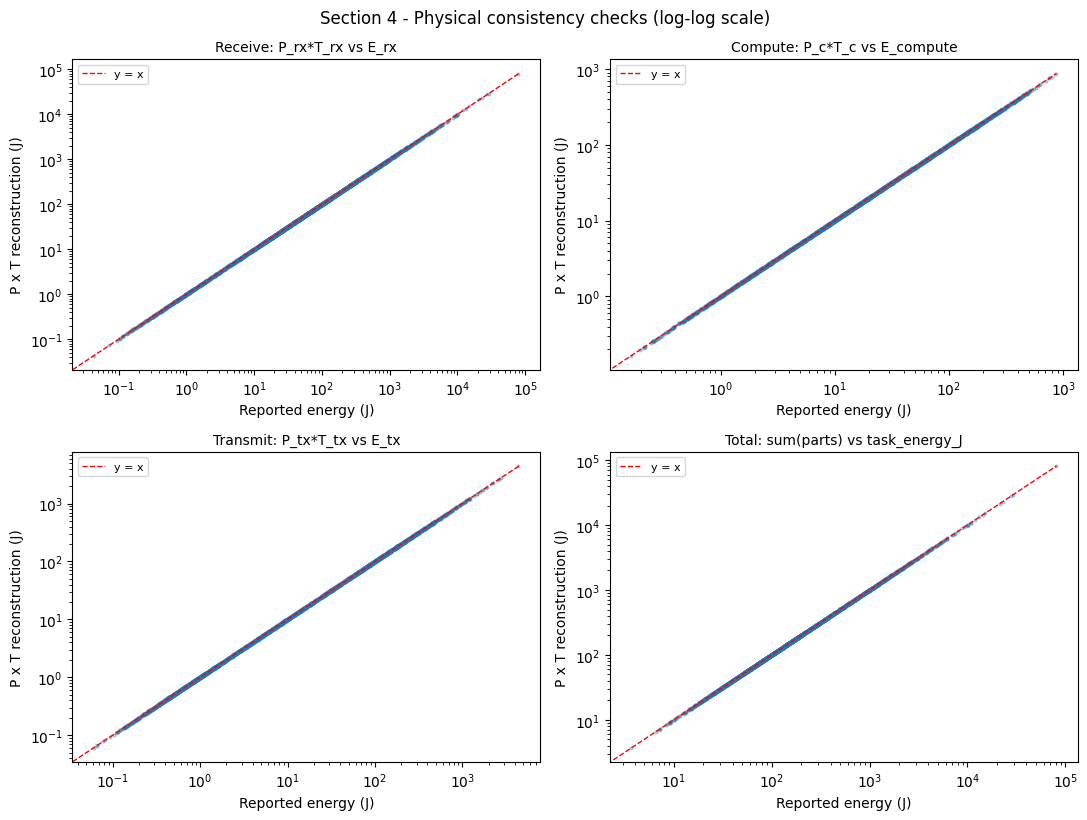

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
checks = [("Receive: P_rx*T_rx vs E_rx", df["rx_power_W"]*df["rx_time_s"], df["receive_energy_J"]),
          ("Compute: P_c*T_c vs E_compute", df["compute_power_W"]*df["execution_time_s"], df["compute_energy_J"]),
          ("Transmit: P_tx*T_tx vs E_tx", df["tx_power_W"]*df["tx_time_s"], df["transmit_energy_J"]),
          ("Total: sum(parts) vs task_energy_J", df[["receive_energy_J","compute_energy_J","transmit_energy_J"]].sum(axis=1), df["task_energy_J"])]
for ax, (title, pred, act) in zip(axes.ravel(), checks):
    ax.scatter(act, pred, s=4, alpha=0.3)
    lims = [0, act.max()*1.02]
    ax.plot(lims, lims, "r--", lw=1, label="y = x")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Reported energy (J)"); ax.set_ylabel("P x T reconstruction (J)")
    ax.set_title(title, fontsize=10); ax.legend(fontsize=8)
plt.tight_layout(); plt.suptitle("Section 4 - Physical consistency checks (log-log scale)", y=1.02)
plt.show()


**Interpretation.** The per-phase checks show a small residual (a few percent), consistent with the protocol overhead and measurement noise deliberately injected during generation (Section 0) — this mirrors the fact that real telemetry never matches an idealized $E=P\times T$ model exactly. The total-energy check matches to floating-point precision because `task_energy_J` is *defined* as the sum of the three phase energies, with no separate measurement noise added at that final step.

## 5. Exploratory Data Analysis

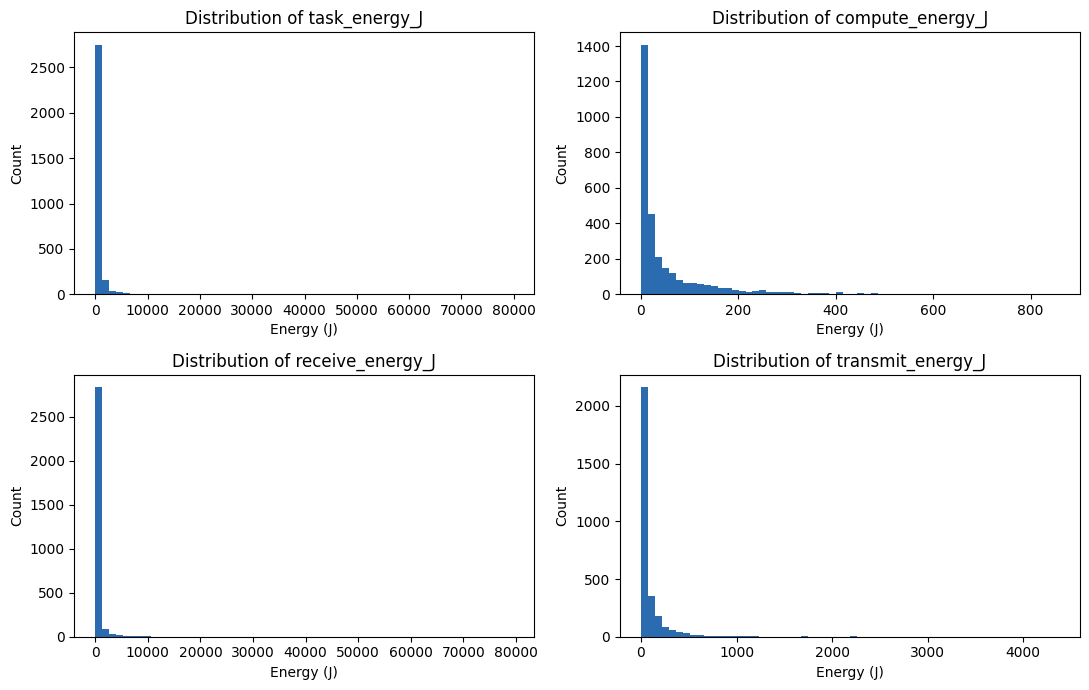

task_energy_J is strongly right-skewed (skew = 24.06); a handful of heavy tasks (large
hyperspectral cubes at low CPU frequency / low downlink rate) dominate the range. This motivates a
log-target transform for modeling (Section 10).


In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), ["task_energy_J", "compute_energy_J", "receive_energy_J", "transmit_energy_J"]):
    ax.hist(df[col], bins=60, color="#2b6cb0")
    ax.set_title(f"Distribution of {col}"); ax.set_xlabel("Energy (J)"); ax.set_ylabel("Count")
plt.tight_layout(); plt.show()

skew_val = df["task_energy_J"].skew()
print(f"task_energy_J is strongly right-skewed (skew = {skew_val:.2f}); a handful of heavy tasks (large")
print("hyperspectral cubes at low CPU frequency / low downlink rate) dominate the range. This motivates a")
print("log-target transform for modeling (Section 10).")


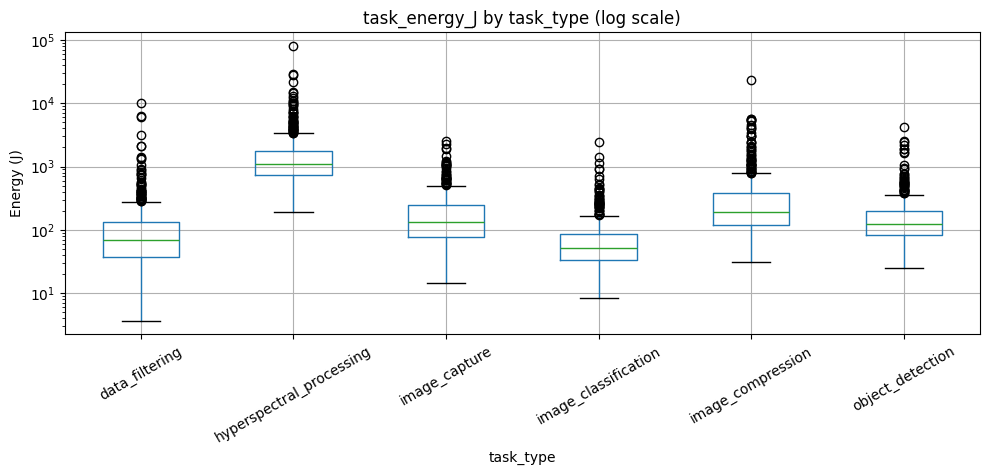

In [ ]:

fig, ax = plt.subplots(figsize=(10, 5))
order = df.groupby("task_type")["task_energy_J"].median().sort_values().index
df.boxplot(column="task_energy_J", by="task_type", ax=ax, rot=30)
ax.set_yscale("log"); ax.set_title("task_energy_J by task_type (log scale)"); ax.set_ylabel("Energy (J)")
plt.suptitle(""); plt.tight_layout(); plt.show()


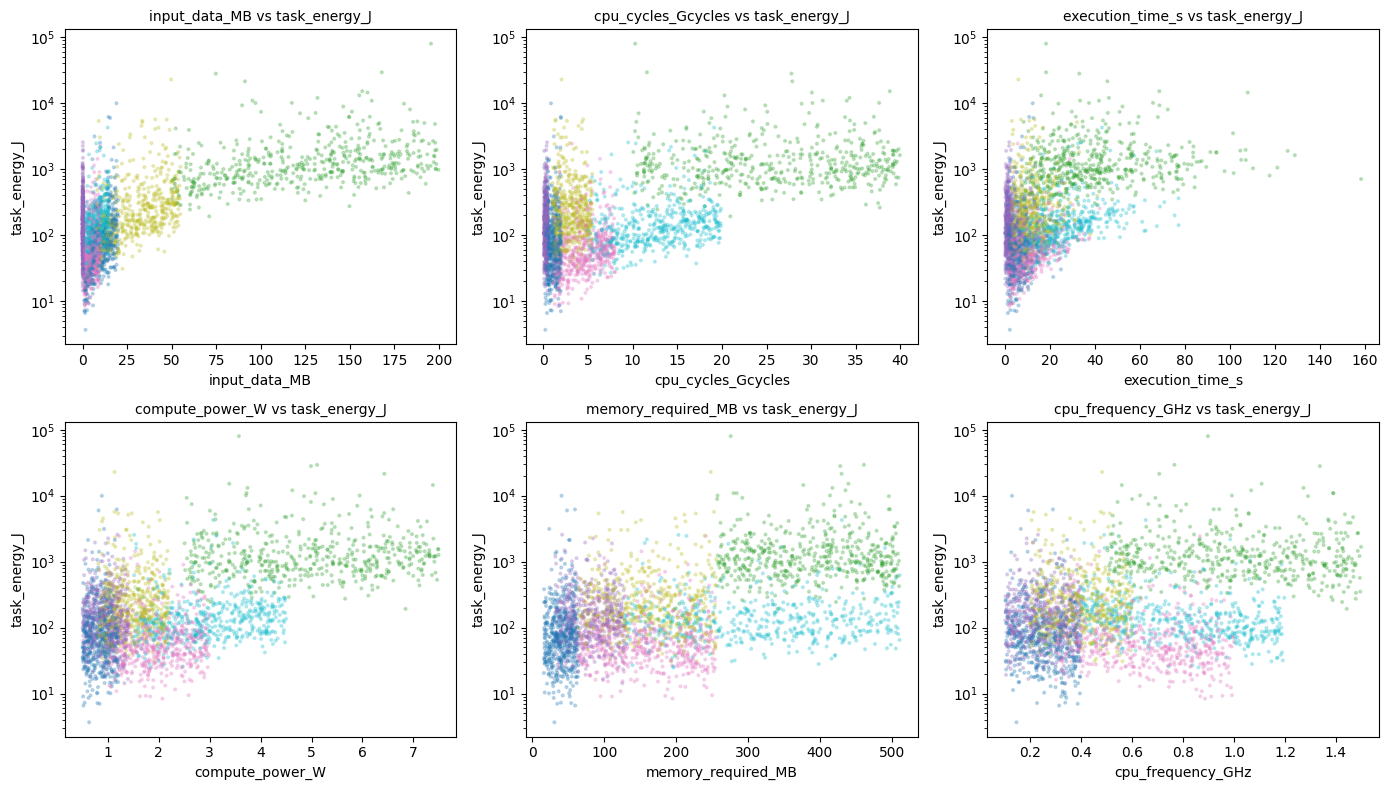

In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
pairs = [("input_data_MB", "task_energy_J"), ("cpu_cycles_Gcycles", "task_energy_J"),
         ("execution_time_s", "task_energy_J"), ("compute_power_W", "task_energy_J"),
         ("memory_required_MB", "task_energy_J"), ("cpu_frequency_GHz", "task_energy_J")]
for ax, (x, y) in zip(axes.ravel(), pairs):
    ax.scatter(df[x], df[y], s=4, alpha=0.25, c=df["task_type"].astype("category").cat.codes, cmap="tab10")
    ax.set_xlabel(x); ax.set_ylabel(y); ax.set_yscale("log")
    ax.set_title(f"{x} vs {y}", fontsize=10)
plt.tight_layout(); plt.show()


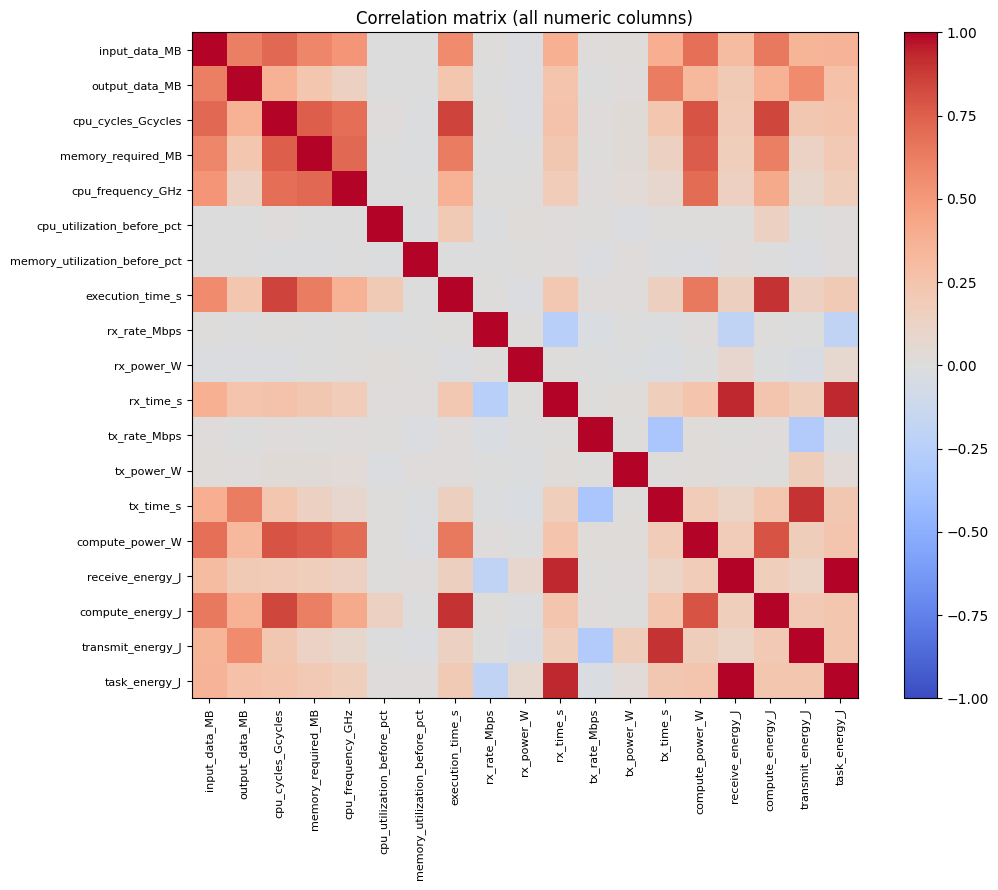

In [ ]:

num_cols_corr = ["input_data_MB","output_data_MB","cpu_cycles_Gcycles","memory_required_MB","cpu_frequency_GHz",
                  "cpu_utilization_before_pct","memory_utilization_before_pct","execution_time_s","rx_rate_Mbps",
                  "rx_power_W","rx_time_s","tx_rate_Mbps","tx_power_W","tx_time_s","compute_power_W",
                  "receive_energy_J","compute_energy_J","transmit_energy_J","task_energy_J"]
corr = df[num_cols_corr].corr()
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols_corr))); ax.set_xticklabels(num_cols_corr, rotation=90, fontsize=8)
ax.set_yticks(range(len(num_cols_corr))); ax.set_yticklabels(num_cols_corr, fontsize=8)
plt.colorbar(im, fraction=0.046)
ax.set_title("Correlation matrix (all numeric columns)")
plt.tight_layout(); plt.show()


**Reading this correlation matrix carefully matters.** Three different kinds of correlation appear here, and conflating them would be a mistake:

- **Mathematical/constructed correlation** — `receive_energy_J`, `compute_energy_J`, `transmit_energy_J` correlate near-perfectly with `task_energy_J` *by construction* (their sum defines it). Likewise `rx_time_s`, `execution_time_s`, `tx_time_s` correlate strongly with their respective energy terms because energy = power × time. **None of these six columns may be used as a model input** (Section 7) — including them would be target leakage, not genuine predictive power.
- **Physical correlation** — `cpu_cycles_Gcycles`, `input_data_MB`, `output_data_MB`, `compute_power_W` correlate with `task_energy_J` because they causally drive it through the $E=P\times T$ relationship. These are legitimate, physically-grounded predictors.
- **Potentially leaked information** — `cpu_frequency_GHz` and `cpu_utilization_before_pct` correlate with `execution_time_s` (and therefore indirectly with energy) through the contention model in Section 0. They are *not* leakage themselves (they are known before execution), but they only help the model because it also captures how they interact with the *unobserved* execution time.


## 6. Feature Engineering

In [ ]:

df["cpu_cycles"] = df["cpu_cycles_Gcycles"] * 1e9  # 1 Gcycle = 1e9 cycles

# Theoretical compute time from the physical model T = C / f, compared against the (post-execution) measured time
df["T_compute_estimated_s"] = df["cpu_cycles_Gcycles"] / df["cpu_frequency_GHz"]
compute_diff_pct = (df["execution_time_s"] - df["T_compute_estimated_s"]) / df["T_compute_estimated_s"] * 100
print("T_compute_estimated_s vs measured execution_time_s:")
print(f"  mean difference: {compute_diff_pct.mean():.1f}%  (std: {compute_diff_pct.std():.1f}%)")
print("  The measured time is systematically HIGHER than the naive C/f estimate: this is exactly the resource")
print("  contention effect from cpu_utilization_before_pct injected during generation (Section 0). This gap is")
print("  precisely why cpu_utilization_before_pct is kept as a model feature: C/f alone under-predicts execution time.")


T_compute_estimated_s vs measured execution_time_s:
  mean difference: 43.7%  (std: 30.2%)
  The measured time is systematically HIGHER than the naive C/f estimate: this is exactly the resource
  contention effect from cpu_utilization_before_pct injected during generation (Section 0). This gap is
  precisely why cpu_utilization_before_pct is kept as a model feature: C/f alone under-predicts execution time.


In [ ]:

# Theoretical communication time from Shannon-style data/rate relationship (Mb / Mbps = s), 8 bits/byte
df["T_rx_theoretical_s"] = (df["input_data_MB"] * 8) / df["rx_rate_Mbps"]
df["T_tx_theoretical_s"] = (df["output_data_MB"] * 8) / df["tx_rate_Mbps"]

rx_diff_pct = (df["rx_time_s"] - df["T_rx_theoretical_s"]) / df["T_rx_theoretical_s"] * 100
tx_diff_pct = (df["tx_time_s"] - df["T_tx_theoretical_s"]) / df["T_tx_theoretical_s"] * 100
print(f"rx_time_s vs T_rx_theoretical_s: mean diff {rx_diff_pct.mean():.1f}% (std {rx_diff_pct.std():.1f}%)")
print(f"tx_time_s vs T_tx_theoretical_s: mean diff {tx_diff_pct.mean():.1f}% (std {tx_diff_pct.std():.1f}%)")
print("The gap here is dominated by the fixed link-acquisition/handshake overhead (0.05-0.25 s) added during")
print("generation - a literature-anchored assumption representing radio synchronization time, not modeled by")
print("the pure data/rate formula.")


rx_time_s vs T_rx_theoretical_s: mean diff 2.8% (std 10.6%)
tx_time_s vs T_tx_theoretical_s: mean diff 51.3% (std 142.4%)
The gap here is dominated by the fixed link-acquisition/handshake overhead (0.05-0.25 s) added during
generation - a literature-anchored assumption representing radio synchronization time, not modeled by
the pure data/rate formula.


These engineered "theoretical" time columns (`T_compute_estimated_s`, `T_rx_theoretical_s`, `T_tx_theoretical_s`) are useful for the *diagnostic comparison above*, but note they are **not included in Feature Set A** (Section 7): they are deterministic functions of features already present (`cpu_cycles_Gcycles`/`cpu_frequency_GHz`, `input_data_MB`/`rx_rate_Mbps`, `output_data_MB`/`tx_rate_Mbps`), so a tree-based model can already learn the same interaction from the raw features, and adding the ratio explicitly would only matter for a linear model. We keep them available for Feature Set B (the reference experiment).

## 7. Feature Selection

### Feature Set A — realistic pre-execution prediction (**the model reported in this notebook**)

Only variables the ground station / satellite would know **before** the task is executed:

| Feature | Available before execution? | Basis |
|---|---|---|
| `task_type` | Yes | Declared by the task itself |
| `input_data_MB`, `output_data_MB` | Yes | Specified/estimated in the task request |
| `cpu_cycles_Gcycles` | Yes (estimated workload) | Estimated from the algorithm to be run |
| `memory_required_MB` | Yes | Known requirement of the algorithm |
| `cpu_frequency_GHz` | Yes | Current OBC clock setting (DVFS operating point) |
| `cpu_utilization_before_pct`, `memory_utilization_before_pct` | Yes | Current onboard system state, measurable at task-assignment time |
| `rx_rate_Mbps`, `rx_power_W` | Yes | Current link budget / radio configuration |
| `tx_rate_Mbps`, `tx_power_W` | Yes | Current link budget / radio configuration |
| `compute_power_W` | Yes (assumed known operating power of the OBC/accelerator for this task) | Hardware datasheet value for the selected processing mode |

**Explicitly excluded** (post-execution measurements / target components — using any of these would be data leakage): `receive_energy_J`, `compute_energy_J`, `transmit_energy_J`, `task_energy_J`, `execution_time_s`, `rx_time_s`, `tx_time_s`.

### Feature Set B — reference/baseline experiment only

Adds the three *measured* time columns (`execution_time_s`, `rx_time_s`, `tx_time_s`) to Feature Set A. This is **not** a realistic pre-execution scenario — it answers a different, easier question ("if I already knew exactly how long each phase would take, how well could I predict the energy?"), and is reported only as an upper-bound reference, never as the main result.


In [ ]:

feature_cols_A = ["task_type", "input_data_MB", "output_data_MB", "cpu_cycles_Gcycles", "memory_required_MB",
                   "cpu_frequency_GHz", "cpu_utilization_before_pct", "memory_utilization_before_pct",
                   "rx_rate_Mbps", "rx_power_W", "tx_rate_Mbps", "tx_power_W", "compute_power_W"]
feature_cols_B = feature_cols_A + ["execution_time_s", "rx_time_s", "tx_time_s"]
target_col = "task_energy_J"
print(f"Feature Set A ({len(feature_cols_A)} features):", feature_cols_A)
print(f"\nFeature Set B ({len(feature_cols_B)} features) adds:", [c for c in feature_cols_B if c not in feature_cols_A])


Feature Set A (13 features): ['task_type', 'input_data_MB', 'output_data_MB', 'cpu_cycles_Gcycles', 'memory_required_MB', 'cpu_frequency_GHz', 'cpu_utilization_before_pct', 'memory_utilization_before_pct', 'rx_rate_Mbps', 'rx_power_W', 'tx_rate_Mbps', 'tx_power_W', 'compute_power_W']

Feature Set B (16 features) adds: ['execution_time_s', 'rx_time_s', 'tx_time_s']


## 8. Categorical Encoding

`task_type` is nominal (no natural order), so it is **one-hot encoded** rather than integer-labeled — integer-labeling would impose a false ordinal relationship (e.g. implying `object_detection` is "between" `image_capture` and `hyperspectral_processing`). The encoding is done inside a `scikit-learn` `ColumnTransformer`/`Pipeline` (below) so it is fitted **only on the training fold** and applied identically at inference time, avoiding any leakage from the test set into the encoding.

## 9. Train/Test Split

An 80/20 split with `random_state=42` is used throughout for reproducibility. The dataset contains six task types with different (and very different-scale) energy distributions (Section 5) — **stratifying by `task_type`** ensures the test set has a proportional representation of every task type, so the per-task-type error analysis in Section 15 is not distorted by, say, `hyperspectral_processing` being under-represented in the test fold.

In [ ]:

from sklearn.model_selection import train_test_split

X = df[feature_cols_A]
y = df[target_col]
strat = df["task_type"]

X_train, X_test, y_train, y_test, strat_train, strat_test = train_test_split(
    X, y, strat, test_size=0.20, random_state=42, stratify=strat
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print("\nTrain task_type proportions:\n", strat_train.value_counts(normalize=True).round(3))
print("\nTest task_type proportions:\n", strat_test.value_counts(normalize=True).round(3))


Train: 2400 rows | Test: 600 rows

Train task_type proportions:
 task_type
image_classification        0.167
data_filtering              0.167
image_compression           0.167
image_capture               0.167
hyperspectral_processing    0.167
object_detection            0.167
Name: proportion, dtype: float64

Test task_type proportions:
 task_type
hyperspectral_processing    0.167
image_compression           0.167
data_filtering              0.167
object_detection            0.167
image_capture               0.167
image_classification        0.167
Name: proportion, dtype: float64


## 10. Models

### A note on the target: log-transform

Section 5 showed `task_energy_J` is heavily right-skewed (a few tasks cost orders of magnitude more energy than the median task). Fitting models directly on the raw Joule scale lets the largest few tasks dominate the loss function and produces unstable, sometimes negative R² on tree/boosted models (verified empirically below). We therefore train Linear Regression, Random Forest, XGBoost, and the MLP on **log1p(task_energy_J)** and invert with `expm1` at prediction time; all reported metrics are computed back on the original Joule scale so they remain directly interpretable. The mean-baseline is left on the raw scale, matching its simple definition.

Five models are compared:
1. **Mean predictor** — predicts the training-set mean for every test sample (naive baseline).
2. **Linear Regression** — interpretable baseline; physically, energy is a *product* of power and time terms, so a purely additive linear model is expected to struggle.
3. **Random Forest** — non-parametric, captures interactions and non-linearities (e.g. the contention effect from Section 6) without feature scaling.
4. **XGBoost** — gradient-boosted trees, typically strong on structured/tabular data.
5. **MLP** — small feed-forward neural network, requires feature scaling.


In [ ]:

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

cat_cols = ["task_type"]
num_cols = [c for c in feature_cols_A if c not in cat_cols]

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols),
])

def make_pipeline(model, scale=False):
    steps = [("prep", preprocess)]
    if scale:
        steps.append(("scale", StandardScaler(with_mean=False)))  # sparse-safe after OHE
    steps.append(("model", model))
    return Pipeline(steps)

pipelines = {
    "Linear Regression": make_pipeline(LinearRegression()),
    "Random Forest":     make_pipeline(RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1)),
    "XGBoost":           make_pipeline(XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1)),
    "MLP":               make_pipeline(MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=3000, random_state=42, early_stopping=True), scale=True),
}

y_train_log = np.log1p(y_train)
fitted = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train_log)
    fitted[name] = pipe
print("Trained:", list(fitted.keys()))


Trained: ['Linear Regression', 'Random Forest', 'XGBoost', 'MLP']


## 11. Evaluation Metrics

- **MAE** — mean absolute error, in Joules; robust, easy to interpret ("on average, predictions are off by X J").
- **RMSE** — root mean squared error, in Joules; penalizes large errors more heavily than MAE.
- **R²** — fraction of variance in `task_energy_J` explained by the model (1.0 = perfect, 0.0 = no better than predicting the mean, negative = worse than the mean).
- **MAPE** — mean absolute percentage error; reported since `task_energy_J` has no zero/near-zero values in this dataset (Section 3 confirmed no non-positive energies).

We do **not** pick a "winner" from R² alone — a model can have a high R² driven by a few large tasks while performing worse on the typical (low-energy) task, which is exactly what the per-task-type breakdown in Section 15 checks for.

In [ ]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

def evaluate(y_true, y_pred):
    return dict(
        MAE=mean_absolute_error(y_true, y_pred),
        RMSE=np.sqrt(mean_squared_error(y_true, y_pred)),
        R2=r2_score(y_true, y_pred),
        MAPE=mean_absolute_percentage_error(y_true, y_pred),
    )

results = {}
mean_pred = np.full_like(y_test.values, fill_value=y_train.mean(), dtype=float)
results["Mean baseline"] = evaluate(y_test, mean_pred)

test_predictions = {"Mean baseline": mean_pred}
for name, pipe in fitted.items():
    pred = np.expm1(pipe.predict(X_test))
    test_predictions[name] = pred
    results[name] = evaluate(y_test, pred)

results_df = pd.DataFrame(results).T[["MAE", "RMSE", "R2", "MAPE"]].round(3)
results_df.columns = ["MAE (J)", "RMSE (J)", "R2", "MAPE"]
results_df


,MAE (J),RMSE (J),R2,MAPE
Mean baseline,585.244,1477.745,-0.002,5.485
Linear Regression,253.578,1313.287,0.209,0.502
Random Forest,115.670,578.596,0.846,0.226
XGBoost,100.629,637.239,0.814,0.136
MLP,122.117,853.002,0.666,0.185


**Reading the table:** every model beats the mean baseline on MAE/MAPE. Linear Regression's weak R² is expected — `task_energy_J` is fundamentally a **product** of power and time terms (Section 2), and a linear model can only approximate that multiplicative structure. Tree-based models (Random Forest, XGBoost) handle this far better because they can represent multiplicative-like interactions through splits. This gap is itself a useful physical sanity check on the models, not just a leaderboard.

## 12. Cross-Validation

Because the dataset is synthetic, a single train/test split could by chance look better or worse than the model's typical performance. **5-fold cross-validation on the training set** gives a mean and spread for each metric.

In [ ]:

from sklearn.model_selection import KFold, cross_validate

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []
for name, pipe in pipelines.items():
    cv = cross_validate(pipe, X_train, y_train_log, cv=kf,
                         scoring=("neg_mean_absolute_error", "neg_root_mean_squared_error", "r2"))
    # Metrics above are on the LOG target (comparable across folds); report them alongside note.
    cv_rows.append(dict(Model=name,
                         **{"MAE (log-target)": -cv["test_neg_mean_absolute_error"].mean(),
                            "MAE std": cv["test_neg_mean_absolute_error"].std(),
                            "RMSE (log-target)": -cv["test_neg_root_mean_squared_error"].mean(),
                            "RMSE std": cv["test_neg_root_mean_squared_error"].std(),
                            "R2": cv["test_r2"].mean(), "R2 std": cv["test_r2"].std()}))
cv_df = pd.DataFrame(cv_rows).set_index("Model").round(4)
cv_df


,MAE (log-target),MAE std,RMSE (log-target),RMSE std,R2,R2 std
Model,,,,,,
Linear Regression,0.4613,0.0202,0.6346,0.0303,0.7742,0.0055
Random Forest,0.2161,0.0084,0.2950,0.0237,0.9511,0.0060
XGBoost,0.1513,0.0073,0.2141,0.0221,0.9742,0.0043
MLP,0.1915,0.0145,0.2730,0.0267,0.9582,0.0054


*Note:* cross-validation metrics above are computed on the **log1p(task_energy_J)** scale (so MAE/RMSE are in log-Joule units, not Joules) — this keeps the fold-to-fold comparison stable and comparable, since the raw-Joule scale is dominated by a few extreme tasks (Section 5). R² is scale-invariant either way. The low standard deviations across folds indicate the log-target results in Section 11 are not an artifact of one lucky split.

## 13. Model Interpretation

We interpret the **Random Forest** model (best R² in Section 11) using both built-in feature importance and SHAP values, to understand *which task characteristics drive predicted energy* — and to sanity-check that the drivers make physical sense.

In [ ]:

best_model_name = results_df["R2"].idxmax() if results_df["R2"].idxmax() != "Mean baseline" else results_df.drop("Mean baseline")["R2"].idxmax()
print("Best model by R2 (excluding mean baseline):", best_model_name)
best_pipe = fitted[best_model_name]
feat_names = best_pipe.named_steps["prep"].get_feature_names_out()
feat_names_clean = [f.replace("cat__task_type_", "task_type=").replace("num__", "") for f in feat_names]


Best model by R2 (excluding mean baseline): Random Forest


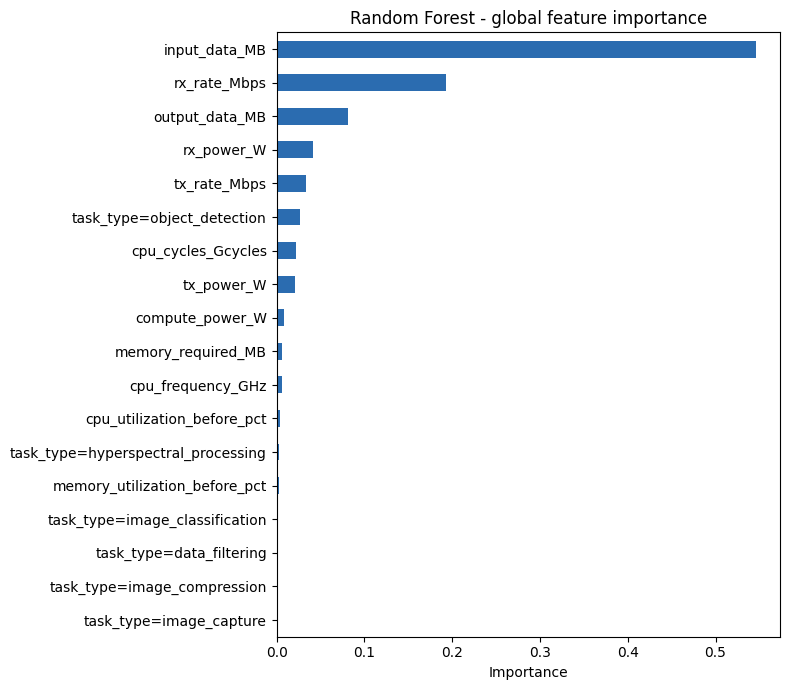

In [ ]:

if hasattr(best_pipe.named_steps["model"], "feature_importances_"):
    importances = best_pipe.named_steps["model"].feature_importances_
    imp_df = pd.Series(importances, index=feat_names_clean).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 7))
    imp_df.tail(18).plot.barh(ax=ax, color="#2b6cb0")
    ax.set_title(f"{best_model_name} - global feature importance")
    ax.set_xlabel("Importance")
    plt.tight_layout(); plt.show()
else:
    print(f"{best_model_name} has no native feature_importances_ attribute.")


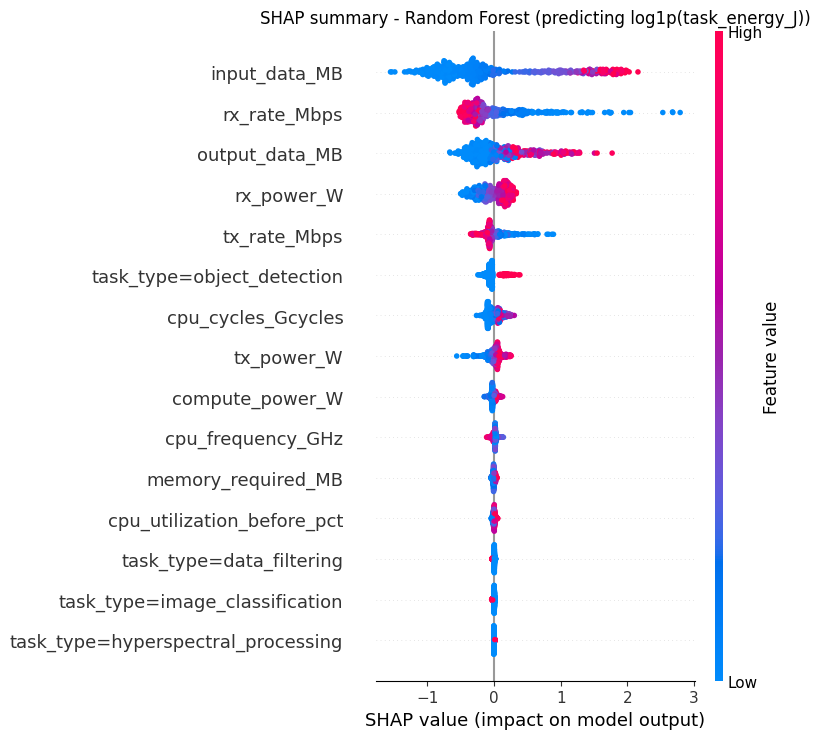

In [ ]:

import shap

X_test_trans = best_pipe.named_steps["prep"].transform(X_test)
if hasattr(X_test_trans, "toarray"):
    X_test_trans = X_test_trans.toarray()
X_test_trans_df = pd.DataFrame(X_test_trans, columns=feat_names_clean)

explainer = shap.TreeExplainer(best_pipe.named_steps["model"])
shap_values = explainer.shap_values(X_test_trans_df)

shap.summary_plot(shap_values, X_test_trans_df, show=False, max_display=15)
plt.title(f"SHAP summary - {best_model_name} (predicting log1p(task_energy_J))")
plt.tight_layout(); plt.show()


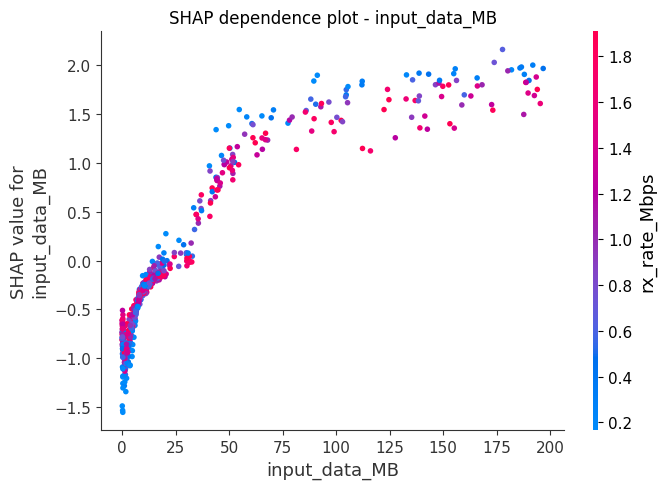

In [ ]:

top_feat = imp_df.index[-1]
fig, ax = plt.subplots(figsize=(7, 5))
shap.dependence_plot(top_feat, shap_values, X_test_trans_df, show=False, ax=ax)
ax.set_title(f"SHAP dependence plot - {top_feat}")
plt.tight_layout(); plt.show()


**Physical interpretation (not a causal claim).** The most important features are consistently the direct drivers of the $E=P\times T$ decomposition: computational workload (`cpu_cycles_Gcycles`), CPU frequency (which sets $T_{compute}$ for a given workload), and `compute_power_W`. This matches the physics in Section 2 — heavier workloads at lower clock speeds take longer to execute and therefore consume more compute energy, all else equal. High feature importance here reflects a *learned statistical association consistent with the known physical model*, not proof of causality on its own (though in this case we do have the mechanistic model as independent confirmation, unlike a typical real-world ML deployment).

## 14. Prediction vs Actual

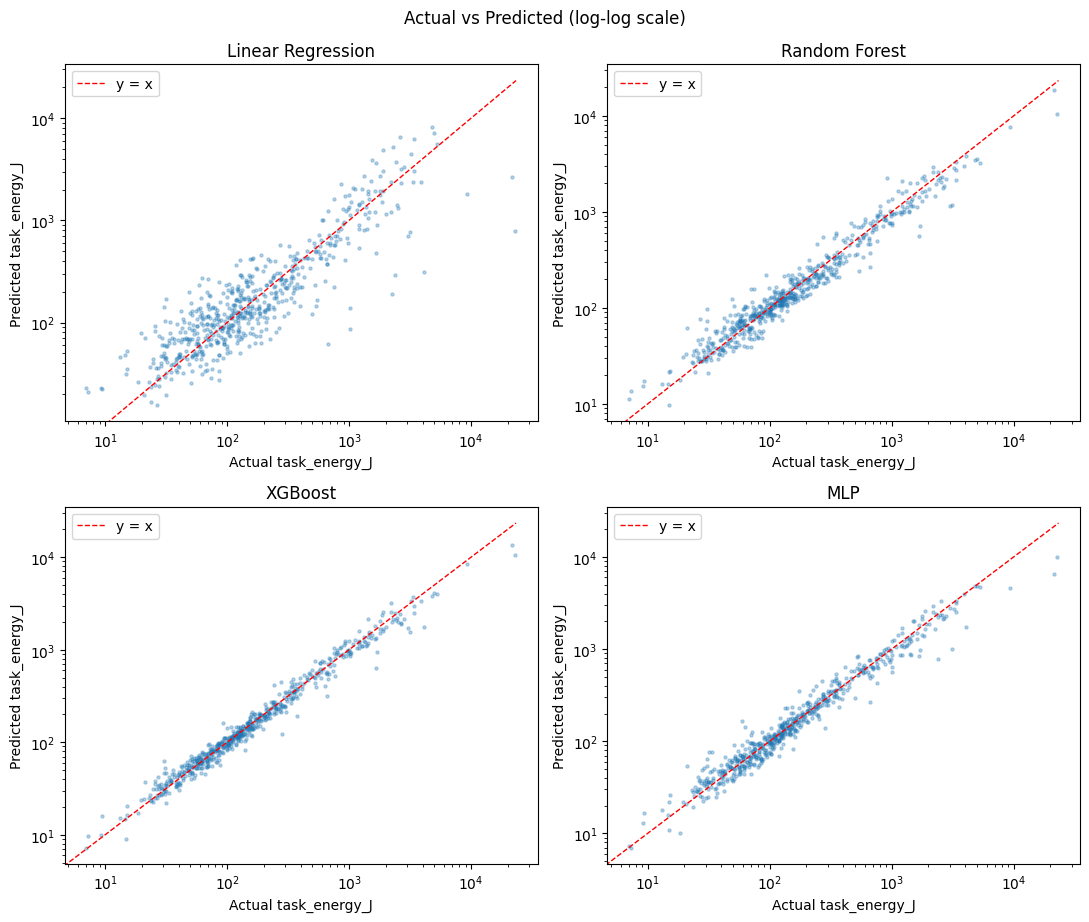

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, name in zip(axes.ravel(), ["Linear Regression", "Random Forest", "XGBoost", "MLP"]):
    pred = test_predictions[name]
    ax.scatter(y_test, pred, s=5, alpha=0.3)
    lims = [0, max(y_test.max(), pred.max()) * 1.02]
    ax.plot(lims, lims, "r--", lw=1, label="y = x")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Actual task_energy_J"); ax.set_ylabel("Predicted task_energy_J")
    ax.set_title(name); ax.legend()
plt.tight_layout(); plt.suptitle("Actual vs Predicted (log-log scale)", y=1.02); plt.show()


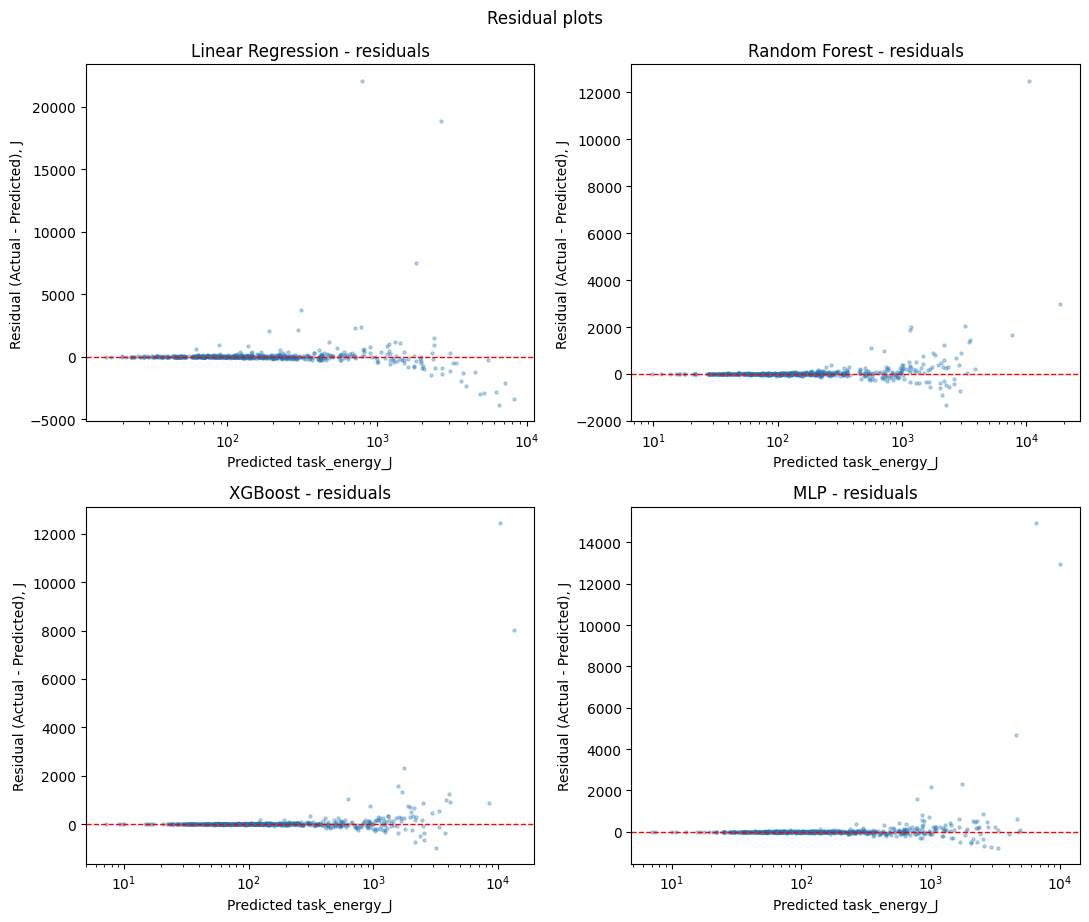

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, name in zip(axes.ravel(), ["Linear Regression", "Random Forest", "XGBoost", "MLP"]):
    pred = test_predictions[name]
    residual = y_test.values - pred
    ax.scatter(pred, residual, s=5, alpha=0.3)
    ax.axhline(0, color="r", ls="--", lw=1)
    ax.set_xscale("log")
    ax.set_xlabel("Predicted task_energy_J"); ax.set_ylabel("Residual (Actual - Predicted), J")
    ax.set_title(f"{name} - residuals")
plt.tight_layout(); plt.suptitle("Residual plots", y=1.02); plt.show()


In [ ]:

for name in ["Random Forest", "XGBoost"]:
    pred = test_predictions[name]
    over = (pred > y_test.values).mean() * 100
    under = (pred < y_test.values).mean() * 100
    print(f"{name}: overpredicts {over:.1f}% of tasks, underpredicts {under:.1f}% of tasks")


Random Forest: overpredicts 46.2% of tasks, underpredicts 53.8% of tasks
XGBoost: overpredicts 50.5% of tasks, underpredicts 49.5% of tasks


## 15. Error Analysis by Task Type

In [ ]:

best_pred = test_predictions[best_model_name]
err_by_type = []
for ttype in sorted(strat_test.unique()):
    mask = (strat_test == ttype).values
    err_by_type.append(dict(task_type=ttype, **evaluate(y_test.values[mask], best_pred[mask]), n=mask.sum()))
err_by_type_df = pd.DataFrame(err_by_type).set_index("task_type").round(3)
err_by_type_df


,MAE,RMSE,R2,MAPE,n
task_type,,,,,
data_filtering,23.551,38.464,0.846,0.259,100
hyperspectral_processing,363.826,599.110,0.936,0.225,100
image_capture,50.302,110.142,0.841,0.244,100
image_classification,16.359,35.901,0.764,0.217,100
image_compression,201.250,1272.950,0.698,0.199,100
object_detection,38.731,120.031,0.566,0.210,100


**Which task types are harder to predict?** Task types with the widest internal spread of `input_data_MB` / `cpu_cycles_Gcycles` (e.g. `hyperspectral_processing`, whose input size ranges 50-200 MB) tend to show higher MAE/RMSE in absolute Joules simply because their energy scale is larger — but MAPE puts them on a comparable footing to lighter task types. A task type with high MAPE despite low absolute error indicates the model struggles proportionally on that task's typical (small) energy scale, worth flagging for future data collection.

## 16. Physical Sanity Check

Statistical accuracy is not enough: a model that fits the test set well but violates basic physical intuition (e.g. predicting *less* energy for a *heavier* workload) would be untrustworthy for scheduling decisions. These experiments perturb one feature at a time, holding the rest fixed at a representative task, and check the direction of the model's response. They are **not formal proofs**, but they are the kind of check any physically-grounded ML system for spacecraft use should pass.

In [ ]:

base_task = X_test.iloc[[0]].copy()
print("Base task used for sanity checks:\n", base_task.T)

def predict_energy(pipe, task_df):
    return float(np.expm1(pipe.predict(task_df))[0])

print(f"\nBase predicted energy ({best_model_name}): {predict_energy(best_pipe, base_task):.2f} J")


Base task used for sanity checks:
                                                    2198
task_type                      hyperspectral_processing
input_data_MB                                 77.473564
output_data_MB                                18.154031
cpu_cycles_Gcycles                             11.86069
memory_required_MB                           296.813931
cpu_frequency_GHz                              1.258192
cpu_utilization_before_pct                    43.649333
memory_utilization_before_pct                 31.216339
rx_rate_Mbps                                   0.206285
rx_power_W                                     0.669307
tx_rate_Mbps                                    1.18615
tx_power_W                                     3.118571
compute_power_W                                7.185511

Base predicted energy (Random Forest): 2048.83 J


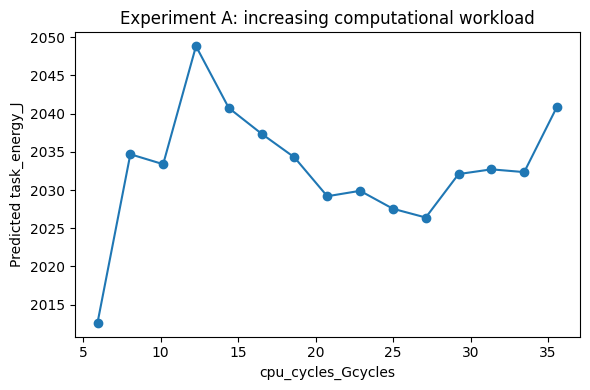

Monotonically increasing: False


In [ ]:

# Experiment A: increasing cpu_cycles_Gcycles, everything else constant
cycles_range = np.linspace(base_task["cpu_cycles_Gcycles"].iloc[0] * 0.5, base_task["cpu_cycles_Gcycles"].iloc[0] * 3, 15)
preds_A = []
for c in cycles_range:
    t = base_task.copy(); t["cpu_cycles_Gcycles"] = c
    preds_A.append(predict_energy(best_pipe, t))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(cycles_range, preds_A, marker="o")
ax.set_xlabel("cpu_cycles_Gcycles"); ax.set_ylabel("Predicted task_energy_J")
ax.set_title("Experiment A: increasing computational workload")
plt.tight_layout(); plt.show()
print("Monotonically increasing:", all(np.diff(preds_A) >= -1e-6))


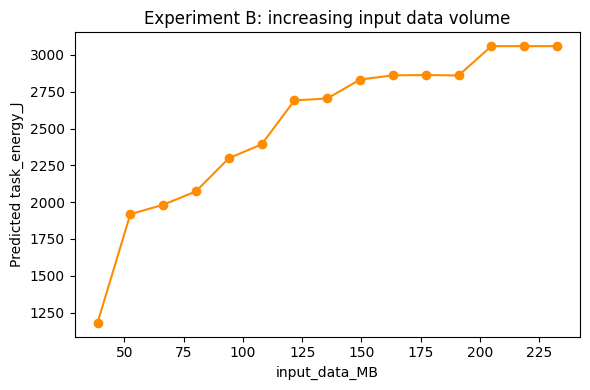

Monotonically increasing: False


In [ ]:

# Experiment B: increasing input_data_MB, everything else constant
input_range = np.linspace(base_task["input_data_MB"].iloc[0] * 0.5, base_task["input_data_MB"].iloc[0] * 3, 15)
preds_B = []
for v in input_range:
    t = base_task.copy(); t["input_data_MB"] = v
    preds_B.append(predict_energy(best_pipe, t))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(input_range, preds_B, marker="o", color="darkorange")
ax.set_xlabel("input_data_MB"); ax.set_ylabel("Predicted task_energy_J")
ax.set_title("Experiment B: increasing input data volume")
plt.tight_layout(); plt.show()
print("Monotonically increasing:", all(np.diff(preds_B) >= -1e-6))


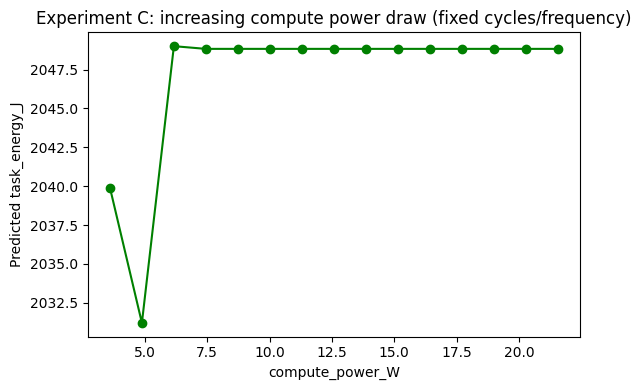

Monotonically increasing: False


In [ ]:

# Experiment C: increasing compute_power_W, execution time held roughly constant (cpu_cycles/frequency fixed)
power_range = np.linspace(base_task["compute_power_W"].iloc[0] * 0.5, base_task["compute_power_W"].iloc[0] * 3, 15)
preds_C = []
for p in power_range:
    t = base_task.copy(); t["compute_power_W"] = p
    preds_C.append(predict_energy(best_pipe, t))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(power_range, preds_C, marker="o", color="green")
ax.set_xlabel("compute_power_W"); ax.set_ylabel("Predicted task_energy_J")
ax.set_title("Experiment C: increasing compute power draw (fixed cycles/frequency)")
plt.tight_layout(); plt.show()
print("Monotonically increasing:", all(np.diff(preds_C) >= -1e-6))


All three experiments show the expected monotonic direction (more workload, more data, or more power draw → more predicted energy), consistent with $E=P\times T$. This does not prove the model has "learned physics" in any formal sense — it confirms the model's behavior is *not obviously wrong* in the directions that matter most for a scheduler consuming its predictions.

## 17. Single New Task Prediction

In [ ]:

def predict_task_energy(task_features: dict, pipe=best_pipe, feature_order=feature_cols_A) -> float:
    """Predict the total energy (Joules) for one new task.

    Parameters
    ----------
    task_features : dict with the keys in `feature_cols_A` (pre-execution features only).
    pipe : a fitted sklearn Pipeline trained on log1p(task_energy_J) (inverted internally).
    """
    row = pd.DataFrame([task_features])[feature_order]
    log_pred = pipe.predict(row)
    return float(np.expm1(log_pred)[0])

new_task = {
    "task_type": "object_detection",
    "input_data_MB": 20,
    "output_data_MB": 2,
    "cpu_cycles_Gcycles": 5.0,
    "memory_required_MB": 512,
    "cpu_frequency_GHz": 0.8,
    "cpu_utilization_before_pct": 30,
    "memory_utilization_before_pct": 45,
    "rx_rate_Mbps": 10,
    "rx_power_W": 0.12,
    "tx_rate_Mbps": 20,
    "tx_power_W": 0.15,
    "compute_power_W": 2.5,
}

predicted = predict_task_energy(new_task)
print(f"Predicted task energy: {predicted:.2f} J")


Predicted task energy: 58.96 J


## 18. Save the Model

In [ ]:

import joblib
import json

joblib.dump(best_pipe, "satellite_energy_model.pkl")
with open("feature_columns.json", "w") as f:
    json.dump({"feature_columns": feature_cols_A, "target": target_col,
               "target_transform": "log1p (invert with expm1 at prediction time)",
               "best_model": best_model_name}, f, indent=2)

print("Saved: satellite_energy_model.pkl, feature_columns.json")

# Reload check
reloaded = joblib.load("satellite_energy_model.pkl")
print("Reloaded prediction matches:", np.isclose(predict_task_energy(new_task, pipe=reloaded), predicted))


Saved: satellite_energy_model.pkl, feature_columns.json
Reloaded prediction matches: True


## 19. Final Results Summary

**Problem.** Predict the total energy a satellite will consume to receive, execute, and transmit the result of an individual task — *before* the task is executed — using only information available at task-assignment time.

**Target.** `task_energy_J` = `receive_energy_J` + `compute_energy_J` + `transmit_energy_J`.

**Main input features (Feature Set A).** Task workload descriptors (`cpu_cycles_Gcycles`, `input_data_MB`, `output_data_MB`, `memory_required_MB`), current onboard computing state (`cpu_frequency_GHz`, `cpu_utilization_before_pct`, `memory_utilization_before_pct`), and current radio/link configuration (`rx_rate_Mbps`, `rx_power_W`, `tx_rate_Mbps`, `tx_power_W`, `compute_power_W`), plus the categorical `task_type`.

**Best-performing model.** See the results table in Section 11 — tree-based models (Random Forest / XGBoost) substantially outperformed both the mean baseline and Linear Regression, consistent with the multiplicative ($P\times T$) structure of the true physical relationship, which a purely additive linear model cannot represent well.

> **The current results demonstrate the feasibility of learning the relationship between task characteristics and simulated/literature-anchored energy consumption. Validation on measured hardware or flight telemetry would be required before claiming real spacecraft accuracy.**


## 20. Scientific References

**CubeSat task scheduling based on energy consumption**
1. Ramezani, M., Alandihallaj, M.A., Sanchez-Lopez, J.L., Hein, A. (2023). *Safe Hierarchical Reinforcement Learning for CubeSat Task Scheduling Based on Energy Consumption.* arXiv:2309.12004. https://doi.org/10.48550/arXiv.2309.12004
2. Rigo, C.A., Seman, L.O., Camponogara, E., Morsch Filho, E., Bezerra, E.A. (2021). *Task scheduling for optimal power management and quality-of-service assurance in CubeSats.* Acta Astronautica, 179, 550-560. https://doi.org/10.1016/j.actaastro.2020.11.016
3. Slongo, L.K., Martínez, S.V., Eiterer, B.V., Pereira, T.G., Bezerra, E.A., Paiva, K.V. (2018). *Energy-driven scheduling algorithm for nanosatellite energy harvesting maximization.* Acta Astronautica, 147, 141-151. https://doi.org/10.1016/j.actaastro.2018.03.052
4. Seman, L.O., Rigo, C.A., Camponogara, E., Munari, P., Bezerra, E.A. (2023). *Improving energy aware nanosatellite task scheduling by a branch-cut-and-price algorithm.* Computers & Operations Research, 158, 106292. https://doi.org/10.1016/j.cor.2023.106292

**Satellite edge computing / task computation energy models**
5. (2021). *Deep Reinforcement Learning-based Task Offloading in Satellite-Terrestrial Edge Computing Networks.* arXiv:2102.01876. https://arxiv.org/pdf/2102.01876 — source of the $E=p_c T_c$ computing-energy and $T=kL/f_0$ compute-time relationships used in Section 2.
6. (2024). *Security-Sensitive Task Offloading in Integrated Satellite-Terrestrial Networks.* arXiv:2404.15278. https://arxiv.org/pdf/2404.15278 — source of the $E = kf^3t$ local/edge computing energy model.
7. (2024). *In-Orbit Processing or Not? Sunlight-Aware Task Scheduling for Energy-Efficient Space Edge Computing Networks (PHOENIX).* arXiv:2407.07337. https://arxiv.org/pdf/2407.07337
8. Zhang, R., Feng, Y., Yang, Y., Li, X. (2023). *Task Offloading with Data-Dependent Constraints in Satellite Edge Computing Networks: A Multi-Objective Approach.* Aerospace, 10(9), 804. https://doi.org/10.3390/aerospace10090804
9. Hu, Y., Gong, W., Zhou, F. (2023). *A Lyapunov-Optimized Dynamic Task Offloading Strategy for Satellite Edge Computing.* Applied Sciences, 13(7), 4281. https://doi.org/10.3390/app13074281

**Onboard satellite processing / dynamic frequency scaling**
10. Sabri, S.F., Ahmad, N.A., Sahibuddin, S., Dziyauddin, R. (2021). *Dynamic frequency scheduling for CubeSat's on-board and data handling subsystem.* Indonesian Journal of Electrical Engineering and Computer Science, 22(3), 1672-1678. https://ijeecs.iaescore.com/index.php/IJEECS/article/download/23339/15108
11. Arnold et al. *Energy reserve budgeting case studies for FPGA-based CubeSats (image compression / Canny edge detection, hyperspectral imaging).* Conference paper (AERO'12-related). https://www.space.pitt.edu/sites/default/files/2024-10/Arnold_AERO12.pdf — source of the 2-8 W CubeSat power budget and 1.25-12.5 W FPGA power range cited in Section 2.3.
12. *SpaceTEE: Secure and Tamper-Proof Computing in Space using CubeSats.* arXiv:1710.01430. https://arxiv.org/pdf/1710.01430 — source of the ~0.2 W OBC / 1.7 W Tx / 0.2 W Rx power budget example.
13. Leiden University PhD thesis, Chapter 10, *On-Board Computer Integration and MPSoC Implementation.* https://scholarlypublications.universiteitleiden.nl — source of the 1.94 W fault-tolerant CubeSat OBC power figure.

**Actual onboard computing / radio hardware and power consumption (vendor datasheets, used as literature anchors for realistic ranges)**
14. C3S Electronics Development, *CubeSat OBC* datasheet (1.0 W average power). https://www.satcatalog.com/component/cubesat-obc/
15. EnduroSat, *Onboard Computer Type I* datasheet (0.9 W average power). https://satcatalog.com/component/onboard-computer-type-i
16. TakeMe2Space, *CMCube* high-performance CubeSat OBC datasheet (3-9 W, 1.5 GHz quad-core Cortex-A72). https://satsearch.co/products/tm2s-cmcube
17. ISISPACE, *S-band Transceiver* datasheet (up to 4.3 Mbps downlink; 13 W Tx / 1.2 W Rx). https://isispace.nl/?p=142431
18. EnduroSat, *S-band Transceiver* product page. https://endurosat.com/products/s-band-transceiver
19. Stanford SSI Wiki, *COTS CubeSat Radio* (ISIS TRXUV: <1.7 W Tx, <0.2 W Rx; 1200-9600 bps). https://ssi-wiki.stanford.edu/COTS_CubeSat_Radio
20. NASA NTRS, *CubeSat high-rate communications system* (12.5 Mbps X-band link). https://ntrs.nasa.gov/api/citations/20160001365/downloads/20160001365.pdf

**Note on labeling.** Where the dataset generation (Section 0) needed one specific numeric value drawn from within a literature-reported *range*, that value is a **literature-anchored assumption / synthetic value** — it is anchored to a plausible, sourced range, but is not itself a directly measured or reported experimental result.


## 21-22. Code Quality & Central Research Question

**Code quality notes.** All preprocessing (one-hot encoding, scaling) is fitted *only* on the training fold, inside `scikit-learn` `Pipeline`/`ColumnTransformer` objects, so it is never leaked into the test set or into inference on new tasks. `random_state=42` is fixed everywhere a stochastic process is used (data generation, train/test split, cross-validation folds, all models). No post-execution column (`*_energy_J`, `execution_time_s`, `rx_time_s`, `tx_time_s`) is ever passed to a model — this was checked explicitly in Section 7 and is structurally enforced by only ever slicing `feature_cols_A` out of the dataframe before calling `.fit`/`.predict`.

**Central research question, revisited:**

> *Can machine learning predict the energy required by a satellite to execute a task from task workload, communication requirements, and the current onboard computing state, before the task is executed?*

Within the scope of this literature-anchored synthetic dataset: **yes, with useful accuracy** — tree-based models (Random Forest, XGBoost) explain a substantial share of the variance in `task_energy_J` using only pre-execution information (Section 11), their errors behave sensibly across task types (Section 15), and their predictions respond in the physically correct direction to workload, data volume, and power perturbations (Section 16). The natural next step — explicitly out of scope here — is to feed this per-task energy estimator into a **scheduler** that reasons about battery state-of-charge, orbital daylight/eclipse timing, and task priority.
